# AI Agent for CVs evaluation

### Importaciones

In [ ]:
import os

# Change the current working directory to the parent directory
os.chdir("../")

# Verify the change
print(f"Current working directory: {os.getcwd()}")

Current working directory: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Materias/NLP2/TP2/NLP-II


In [ ]:
%pip install -r ./requirements.txt --quiet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Data Models
from pydantic import BaseModel
import sqlite3

# Typing
from typing import TypedDict, List
from typing_extensions import Annotated

# LLM and Vector Store setup
from src.vectorstore import setup_vectorstore
from src.ingestion import load_pdf_content, process_text_to_docs
from src.rag_engine import get_llm

# LangGraph
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.sqlite import SqliteSaver

# LangChain Core Messages
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.documents import Document
from langchain_classic.chains import RetrievalQA

# Retrying
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type

# Display
from IPython.display import display, Markdown, Image
import json

/Users/alejandrolloveras/Documents/ESTUDIO/UBA/Materias/NLP2/TP2/NLP-II/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Create an in-memory connection
conn = sqlite3.connect(":memory:", check_same_thread=False)

# Initialize the saver with the connection
memory = SqliteSaver(conn)

In [ ]:
# The TypeDdict is imported from the typing module for defining a type of dictionary with specific values keys and typed values.
class AgentState(TypedDict):
    task:str
    question: str
    plan:str
    context: Annotated[List[Document], "accumulate"]
    answer: str
    content: Annotated[List[str], "accumulate"]
    error: str

In [ ]:
# Define a Pydantic model for queries
class Queries(BaseModel):
    queries: List[str]

## Inicialización (CONFIG)

In [ ]:
class User:
    def __init__(self, name: str, path: str):
        self.name = name
        self.path = path

In [ ]:
# Definición de usuarios y sus respectivos CVs
user1 = User(name="John", path="ai_engineer_cv_extended.pdf")
user2 = User(name="Emily", path="ai_bigtech_cv.pdf")

### Prompts

In [ ]:
PLAN_PROMPT = """You are an expert writer tasked with drafting a high-level outline for evaluating CVs, curricula vitae, or resumes.
Write this outline for each of the CVs provided by the user. Provide a summary of the main characteristics of the given document.
You can read the CV from the output of the load_pdf_texts_from_folder function.
Maximum 100 words."""

In [ ]:
LLM_PROMPT_USER1 = """
You are an assistant that converts user goals into specific search queries to extract useful information from resumes. 
Only proceed if the candidate's name "{user1.name}" is explicitly mentioned in the {context}.

Generate 2 to 5 **short, specific** search queries related to evaluating candidates' skills, experience, and strengths.

Respond in this format:
{
  "queries": ["What are the candidate's main skills?", "What work experience is listed?", ...]
}

Call the generate function or agent or {context} to answer the questions.

Contexto: {context}
""".replace("{user1.name}", user1.name)

In [ ]:
LLM_PROMPT_USER2 = """
You are an intelligent assistant tasked with transforming a user's goal into targeted search queries to help evaluate resume content. Your objective is to generate concise and specific queries that retrieve relevant details about a candidate's skills, experience, and strengths.

Proceed only if the candidate's name "{user2.name}" is explicitly mentioned in the {context}. If "{user2.name}" is not mentioned, respond with the following JSON exactly as shown:

{
  "error": "I cannot provide the evaluation because {user2.name} is not the candidate mentioned in the document."
}

If "{user2.name}" is present, generate 2 to 5 short, focused queries that could help evaluate her qualifications.

Respond only in the following JSON format:
{
  "queries": [
    "What are {user2.name}'s key technical skills?",
    "What job roles has {user2.name} previously held?",
    "Does {user2.name} have experience in data analysis?",
    "What certifications does {user2.name} have?",
    "What industries has {user2.name} worked in?"
  ]
}
""".replace("{user2.name}", user2.name)


### Data Ingestion

In [ ]:
# # Ingesta controlada
# text = load_pdf_content(PDF_FILE_PATH)
# docs = process_text_to_docs(text, PDF_FILE_PATH)

# # Vectorstore persistente
# vectorstore = setup_vectorstore(documents=docs, reindex=True) # True solo la primera vez

In [ ]:
# 1. Definir la lista de usuarios a procesar
users_to_ingest = [user1, user2]
all_docs = []

print("⬆️ Iniciando Ingesta de Datos para Usuarios …")

for user in users_to_ingest:
    print(f"📄 Procesando: {user.path}")
    
    # Validar que el archivo exista antes de intentar leerlo
    print(os.path.join("data", user.path))
    if os.path.exists(os.path.join("data", user.path)):
        # Ajuste de ruta si está en la carpeta 'data'
        actual_path = user.path 
        
        # Cargar y procesar
        try:
            # Cargamos el texto crudo
            raw_text = load_pdf_content(actual_path)
            
            # Convertimos a Documentos (Chunks)
            # IMPORTANTE: Pasamos 'user.path' (el nombre del archivo) como source
            # para que coincida con el filtro del Evaluator más adelante.
            user_docs = process_text_to_docs(raw_text, user.path) 
            
            all_docs.extend(user_docs)
            print(f"   ✅ Éxito: {len(user_docs)} chunks generados.")
        except Exception as e:
            print(f"   ❌ Error procesando {user.name}: {e}")
    else:
        print(f"   ⚠️ Archivo no encontrado: {user.path}")

# 2. Vectorstore persistente (Subida en lote)
if all_docs:
    print(f"\n💾 Subiendo {len(all_docs)} documentos totales al Vector Store...")
    # reindex=True borrará lo anterior y subirá los nuevos CVs
    vectorstore = setup_vectorstore(documents=all_docs, reindex=True)
    print("✅ Ingesta completada.")
else:
    print("❌ No fueron encontrado documentos para ingerir.")

⬆️ Iniciando Ingesta de Datos para Usuarios …
📄 Procesando: ai_engineer_cv_extended.pdf
data/ai_engineer_cv_extended.pdf
Resolved path: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Materias/NLP2/TP2/NLP-II/data/ai_engineer_cv_extended.pdf
Loading PDF from: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Materias/NLP2/TP2/NLP-II/data/ai_engineer_cv_extended.pdf
Extracted 4203 characters from the PDF.
Resolved path: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Materias/NLP2/TP2/NLP-II/data/ai_engineer_cv_extended.pdf
   ✅ Éxito: 10 chunks generados.
📄 Procesando: ai_bigtech_cv.pdf
data/ai_bigtech_cv.pdf
Resolved path: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Materias/NLP2/TP2/NLP-II/data/ai_bigtech_cv.pdf
Loading PDF from: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Materias/NLP2/TP2/NLP-II/data/ai_bigtech_cv.pdf
Extracted 2787 characters from the PDF.
Resolved path: /Users/alejandrolloveras/Documents/ESTUDIO/UBA/Materias/NLP2/TP2/NLP-II/data/ai_bigtech_cv.pdf
   ✅ Éxito: 6 c

/Users/alejandrolloveras/Documents/ESTUDIO/UBA/Materias/NLP2/TP2/NLP-II/src/vectorstore.py:28: LangChainDeprecationWarning: The class `Pinecone` was deprecated in LangChain 0.0.3 and will be removed in 1.0.0. Use `PineconeVectorStore` instead.
  vectorstore = PineconeVectorStore(index=index, embedding=embeddings)


-> Subiendo batch 1...
✅ Ingesta completada.


# Construcción del Grafo

In [ ]:
def plan_node(state):
    # 1. Instanciamos el modelo usando la configuración centralizada
    # Esto leerá LLM_PROVIDER de settings.py y devolverá ChatOpenAI o ChatGoogleGenerativeAI
    model = get_llm() 
    
    # 2. Construimos los mensajes (igual que antes)
    # Asegúrate de que PLAN_PROMPT esté definido como constante o impórtalo
    messages = [
        SystemMessage(content=PLAN_PROMPT), 
        HumanMessage(content=state['task'])
    ]
    
    # 3. Invocamos al modelo
    response = model.invoke(messages)
    
    # 4. Retornamos la actualización del estado
    return {"plan": response.content}

In [ ]:
def retriever(state: AgentState):
     # Configuramos el vectorstore (sin reindexar)
     vs = setup_vectorstore(reindex=False)

     # Definimos la consulta
     query = state.get("question") or state.get("task")

     # Si el estado tiene un candidato objetivo, filtramos
     filter_dict = {}
     if "candidate_name" in state: 
          filter_dict = {"source": f"{state['candidate_name']}.pdf"}

     retriever = vs.as_retriever(search_kwargs={'k': 3, 'filter': filter_dict})
     relevant_docs = retriever.invoke(query)
     print(f"Docs recuperados para '{query}': {len(relevant_docs)}")

     return {"context": relevant_docs, "query":query}

In [ ]:
def generate(state: AgentState):
    model = get_llm()
    
    context_docs = state.get("context", [])
    content_chunks = state.get("content", [])

    print("Context docs:", context_docs)
    print("Content chunks:", content_chunks)

    # Combine available content
    if context_docs:
        docs_content = "\n\n".join(texts.page_content for texts in context_docs if hasattr(texts, "page_content"))
    elif content_chunks:
        docs_content = "\n\n".join([str(chunk) for chunk in content_chunks])
    else:
        return {"answer": "No context or content available for answer generation."}

    # Get a safe fallback question string
    question = state.get('question') or state.get('task') or "Describe the main characteristics of the resumes."

    prompt_text = f"""Eres un asistente experto. Usa el siguiente contexto para responder a las preguntas.

Pregunta: {question}

Contexto:
{docs_content}

Respuesta:"""

    try:
        response = model.invoke([HumanMessage(content=prompt_text)])
        return {"answer": response.content}
    except Exception as e:
        print("Error during model invocation:", e)
        return {"answer": f"Error invoking model: {str(e)}"}

In [ ]:
# Define una función de retry que espera exponencialmente (1s, 2s, 4s...)
# y reintenta 3 veces.
@retry(
    wait=wait_exponential(multiplier=1, min=2, max=10),
    stop=stop_after_attempt(3),
    retry=retry_if_exception_type((
        Exception # Puedes cambiar esto a RateLimitError si el error es específico
    )),
    before_sleep=lambda retry_state: print(f"    ⏳ Límite alcanzado, reintentando en {retry_state.seconds_since_start}s...")
)
def _invoke_structured_llm(structured_llm, messages):
    # Función auxiliar que encapsula la llamada que puede fallar
    return structured_llm.invoke(messages)

In [ ]:
def _check_file_existence(source_filter: str):
    """
    Verifica la existencia del archivo priorizando la carpeta 'data'.
    """
    # Esto evita gastar tokens de LLM si el archivo ni siquiera existe.
    if source_filter:
        # Limpiamos el input para obtener solo el nombre del archivo (ej: 'cv.pdf')
        # Esto previene errores si source_filter viene como 'data/cv.pdf' -> 'data/data/cv.pdf'
        filename = os.path.basename(source_filter).strip()
        
        # Definimos las rutas posibles
        # 1. En la carpeta 'data' (Prioridad según tu indicación)
        # 2. Ruta tal cual vino (por si es absoluta)
        possible_paths = [
            os.path.join("data", filename),
            source_filter
        ]
        
        # Verificamos
        file_exists = any(os.path.exists(path) for path in possible_paths)
        
        if not file_exists:
            # Agregamos info de debug (CWD) por si el script corre en otro path
            cwd = os.getcwd()
            msg = f"⚠️ ALERTA: El documento '{filename}' no se encuentra en el disco. (Buscado en 'data/' y CWD: {cwd}). Se cancela la evaluación."
            print(msg)
            # Retornamos inmediatamente para no invocar al LLM
            return {"content": [], "error": msg}
        else:
            print(f"✅ El documento '{filename}' fue encontrado.")
            return None
    else:
        print("⚠️ ALERTA: No se proporcionó ningún filtro de fuente. Se cancela la evaluación.")
        return {"content": [], "error": "No source filter provided."}

In [ ]:
def _run_evaluation(state: AgentState, system_prompt: str, source_filter: str = None):
    """
    Función auxiliar para ejecutar la evaluación de un candidato.
    
    Args:
        state: Estado del grafo.
        system_prompt: Prompt específico (USER1 o USER2).
        source_filter: Nombre del archivo PDF para filtrar (ej: 'cvFS.pdf'). 
                       Esto es CRÍTICO para evitar que un CV responda preguntas de otro.
    """
    # 0. Validación de Existencia del Documento (Pre-flight Check)
    preflight_check = _check_file_existence(source_filter)
    if preflight_check is not None:
        return preflight_check

    # 1. Obtenemos el LLM configurado (OpenAI o Gemini)
    model = get_llm()
    
    # 2. Generación de Queries Estructuradas
    structured_llm = model.with_structured_output(Queries)
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=state.get('task', ''))
    ]

    try:
        # Usamos la función con retry
        queries = _invoke_structured_llm(structured_llm, messages)
        print(f"Queries ({source_filter}):", queries)
    except Exception as e:
        # Esto atrapará el error si todos los reintentos fallan (incluido el RPD)
        return {"content": [], "error": f"Failed to generate queries after retries: {e}"}

    if not queries or not getattr(queries, "queries", None):
        return {"content": [], "error": "No queries generated"}

    # 3. Configuración del Retriever
    # Usamos setup_vectorstore con reindex=False para eficiencia
    vs = setup_vectorstore(reindex=False)
    
    # 4. Filtro de Metadatos
    # Si source_filter es provisto, Pinecone solo buscará en ese documento.
    search_kwargs = {"k": 3}
    if source_filter:
        search_kwargs["filter"] = {"source": source_filter}

    # 5. Configuración de la cadena QA
    # Reutilizamos el mismo 'model' obtenido de get_llm()
    qa_chain = RetrievalQA.from_chain_type(
        llm=model, 
        chain_type="stuff",
        retriever=vs.as_retriever(search_type="similarity", search_kwargs=search_kwargs),
        return_source_documents=False
    )

    # 6. Ejecución de preguntas
    content = []
    for q in queries.queries:
        if not isinstance(q, str):
            continue
        try:
            result = qa_chain.invoke({"query": q})
            print(f"Answer: {result['result']}")
            content.append(result["result"])
        except Exception as e:
            # Manejo de casos donde no hay documentos (ej: user_name no encontrado)
            print(f"Error retrieving answer: {e}")
            content.append("No information found.")

    return {"content": content}

In [ ]:
# LLM Nodes para cada usuario
def llm_user1_node(state: AgentState):
    return _run_evaluation(state, LLM_PROMPT_USER1, source_filter=user1.path)

def llm_user2_node(state: AgentState):
    return _run_evaluation(state, LLM_PROMPT_USER2, source_filter=user2.path)

In [ ]:
# Condición de finalización
def should_continue(state: AgentState):
    """
    Decide el siguiente paso basado en si hubo errores.
    Retorna: "continue" (si todo está bien) o END (si hay error).
    """
    error = state.get("error")
    
    # Si detectamos un error (ej: PDF no encontrado), cortamos el flujo
    if error:
        print(f"⛔ Interrupción del grafo detectada: {error}")
        return END
    
    # Si no hay error, seguimos
    return "continue"

---

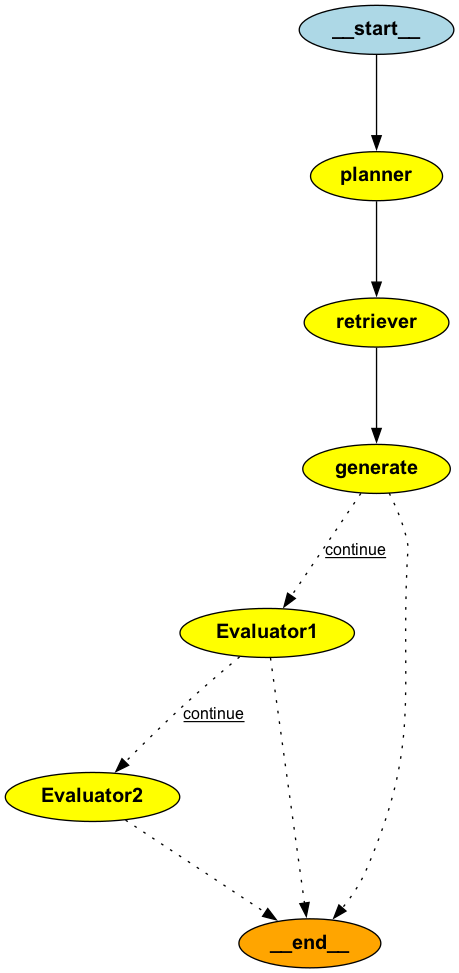

In [ ]:
# Construcción del grafo de estados
builder = StateGraph(AgentState)

# Definición de nodos
builder.add_node("planner", plan_node)
builder.add_node("Evaluator1", llm_user1_node)
builder.add_node("Evaluator2", llm_user2_node)
builder.add_node("generate", generate)
builder.add_node("retriever", retriever)

# Definición de aristas
builder.set_entry_point("planner")
builder.set_finish_point("Evaluator2")  
builder.add_edge("planner", "retriever")
builder.add_edge("retriever", "generate")
builder.add_edge("generate", "Evaluator1")
builder.add_edge("Evaluator1", "Evaluator2")

# Aristas condicionales
# Decisión 1: después de 'generate', ¿Vamos a Evaluator1 o terminamos?
builder.add_conditional_edges(
    "generate",          # Nodo origen
    should_continue,     # Función lógica
    {
        "continue": "Evaluator1",  # Camino feliz
        END: END                   # Camino de error (Stop)
    }
)

# Decisión 2: después de 'Evaluator1', ¿Vamos a Evaluator2 o terminamos?
builder.add_conditional_edges(
    "Evaluator1",
    should_continue,
    {
        "continue": "Evaluator2",  # Camino feliz
        END: END                   # Camino de error (Stop)
    }
)

# Decisión 3: después de 'Evaluator2', Finalizar siempre (o chequear error final).
builder.add_conditional_edges(
    "Evaluator2",
    should_continue,
    {
        "continue": END,
        END: END
    }
)

# Finalización del grafo con checkpointer
graph = builder.compile(checkpointer=memory)

# Visualización
# 4. Visualización Robusta
try:
    from IPython.display import Image, display
    # Intentamos generar la imagen con Graphviz
    display(Image(graph.get_graph().draw_png()))

except Exception as e:
    print(f"⚠️ Aviso: No fue posible visualizar el grafo.")
    print("(No afecta la ejecución del agente, solo la visualización del diagrama)")
    print(f"Error detallado: {e}")

# Output

In [ ]:
# Simulación del stream y de las salidas
thread = {"configurable": {"thread_id": "1"}}

# Función para imprimir una salida legible por el usuario
def print_pretty_output():
    initial_state = {
        "task": "Evalua cada uno de los cvs proporcionados. Indica las principales características del evaluado destacando sus fortalezas.",
        "content": []
    }

    print("🔄 Iniciando Ejecución del Grafo:")

    for step in graph.stream(initial_state, thread):
        # 'step' es un dict como {'Evaluator2': {'content': [...]}}
        for node_name, node_output in step.items():
            
            # Header for the Node
            markdown_text = f"### 🤖 Paso: `{node_name}`\n"
            
            # 1. Handle 'content' (List of answers from Evaluators)
            if "content" in node_output and isinstance(node_output["content"], list):
                markdown_text += "**Resultados:**\n"
                for item in node_output["content"]:
                    # Clean up "I don't know" or empty responses if you want
                    if item.strip():
                        markdown_text += f"* {item}\n"
            
            # 2. Handle 'plan' (From Planner node)
            elif "plan" in node_output:
                markdown_text += f"**📝 Plan Generado:**\n\n{node_output['plan']}\n"
            
            # 3. Handle 'answer' (From simple generation node)
            elif "answer" in node_output:
                markdown_text += f"**💡 Respuesta:**\n\n{node_output['answer']}\n"
            
            # 4. Handle 'context' (From Retriever node)
            elif "context" in node_output:
                query_used = node_output.get('query', 'N/A')
                markdown_text += f"**🔍 Búsqueda:** `{query_used}`\n\n"
                markdown_text += "**📄 Documentos Recuperados:**\n"
                
                # Iteramos los documentos para mostrarlos bonitos en vez de romper el JSON
                for i, doc in enumerate(node_output["context"]):
                    # Limpiamos un poco el texto para que no ocupe toda la pantalla
                    snippet = doc.page_content[:200].replace('\n', ' ') + "..."
                    source = doc.metadata.get("source", "Desconocido")
                    markdown_text += f"> **{i+1}. [{source}]**: {snippet}\n\n"

            # 5. Fallback for other types (evita el error JSON serializable)
            else:
                # default=str convierte cualquier objeto desconocido a su representación en string
                markdown_text += f"```json\n{json.dumps(node_output, indent=2, default=str)}\n```"

            markdown_text += "\n---"
            # Render Markdown
            display(Markdown(markdown_text))

# Ejecución (llamadas a la función)
print_pretty_output()

🔄 Iniciando Ejecución del Grafo:


### 🤖 Paso: `planner`
**📝 Plan Generado:**

Claro, por favor, proporciona los textos de los CVs que deseas que evalúe. Una vez que los tengas, los procesaré y te ofreceré un resumen de las características principales de cada uno, resaltando sus fortalezas.

---

Docs recuperados para 'Evalua cada uno de los cvs proporcionados. Indica las principales características del evaluado destacando sus fortalezas.': 3


### 🤖 Paso: `retriever`
**🔍 Búsqueda:** `N/A`

**📄 Documentos Recuperados:**
> **1. [ai_engineer_cv_extended.pdf]**: analytics. Resume Intelligence Engine RAG■enhanced LLM system capable of parsing, embedding, and benchmarking resumes for HR departments. Certifications  AWS Certified Machine Learning Engineer – Spe...

> **2. [Desconocido]**: Retrieval-Augmented Generation (RAG) pipelines, and multimodal deep learning models. Expert in LLM architecture, embeddings, model compression, fine■tuning strategies,...

> **3. [ai_engineer_cv_extended.pdf]**: Professional Experience Lead AI Engineer – NovaMind Technologies (2022–Present)  Led architecture of a next■generation enterprise RAG system for 100M+ documents using Pinecone and LlamaIndex.  Built...


---

Context docs: [Document(id='doc_8', metadata={'source': 'ai_engineer_cv_extended.pdf'}, page_content='analytics.\nResume Intelligence Engine\nRAG■enhanced LLM system capable of parsing, embedding, and benchmarking resumes for HR\ndepartments.\nCertifications\n\x7f AWS Certified Machine Learning Engineer – Specialty\n\x7f Google Professional Cloud Architect\n\x7f TensorFlow Developer Certification\n\x7f Stanford Machine Learning Certificate (Andrew Ng)\nPublications\n\x7f “Hybrid Retrieval Strategies for Large■Scale RAG Systems,” 2023\n\x7f “Optimizing Transformer Inference on Edge Devices,” ICML Workshop, 2022\nAwards'), Document(id='CV_3', metadata={'filename': 'ai_engineer_cv.pdf'}, page_content='Retrieval-Augmented Generation (RAG) pipelines,\nand multimodal deep learning models. Expert in LLM architecture, embeddings, model compression,\nfine■tuning strategies,'), Document(id='doc_4', metadata={'source': 'ai_engineer_cv_extended.pdf'}, page_content='Professional Experience\nLead AI

### 🤖 Paso: `generate`
**💡 Respuesta:**

Basándome en el CV proporcionado, evalúo al candidato de la siguiente manera:

**Principales Características y Fortalezas del Evaluado:**

Este candidato se destaca como un **ingeniero de IA altamente especializado y con experiencia práctica en la vanguardia de la inteligencia artificial, particularmente en el campo de los Modelos de Lenguaje Grandes (LLMs) y la generación aumentada por recuperación (RAG).**

Sus fortalezas principales incluyen:

*   **Profunda Experiencia en RAG y LLMs:** El candidato demuestra un conocimiento exhaustivo de los sistemas RAG y una comprensión profunda de la arquitectura de LLMs. Esto se evidencia en su rol como "Lead AI Engineer" donde lideró la arquitectura de un sistema RAG a gran escala y construyó un ecosistema de agentes LLM.
*   **Habilidades Técnicas Sólidas y Diversas:** Posee una combinación de certificaciones reconocidas en áreas clave como Machine Learning (AWS, TensorFlow, Stanford), arquitectura en la nube (Google Cloud) y experiencia práctica en tecnologías específicas como Pinecone y LlamaIndex. Esto indica una base técnica amplia y la capacidad de aplicar conocimientos en entornos prácticos.
*   **Capacidad de Innovación y Optimización:** La mejora del 42% en la precisión de recuperación mediante la optimización de embeddings y el ajuste fino específico del dominio resalta su habilidad para identificar cuellos de botella, implementar soluciones efectivas y lograr mejoras medibles en el rendimiento de los sistemas de IA.
*   **Experiencia en Investigación y Publicaciones:** La inclusión de publicaciones en conferencias relevantes (ICML Workshop) y temas de actualidad como "Hybrid Retrieval Strategies for Large-Scale RAG Systems" sugiere una mente investigadora, la capacidad de contribuir al avance del campo y de mantenerse al día con las últimas tendencias.
*   **Liderazgo y Gestión de Proyectos:** Su rol como "Lead AI Engineer" implica responsabilidades de liderazgo, arquitectura y ejecución de proyectos complejos, lo que indica capacidad para guiar equipos y dirigir el desarrollo de soluciones de IA.
*   **Comprensión de Múltiples Aspectos de LLMs:** La mención de experiencia en "embedding, model compression, fine-tuning strategies" demuestra una comprensión holística de los desafíos y las soluciones relacionadas con el despliegue y la optimización de LLMs.
*   **Enfoque en la Escalabilidad y Eficiencia:** La arquitectura de un sistema RAG para "100M+ documents" y la investigación sobre "Optimizing Transformer Inference on Edge Devices" indican una mentalidad orientada a la escalabilidad, el rendimiento y la eficiencia, aspectos cruciales en entornos empresariales.
*   **Diseño de Estrategias de Recuperación Complejas:** La experiencia en el diseño de "hybrid vector + keyword retrieval strategy using BM25, sparse embeddings, and metadata" muestra una habilidad avanzada para combinar diferentes enfoques de recuperación para obtener resultados óptimos.

En resumen, el evaluado es un profesional de IA con una sólida base teórica y una probada experiencia práctica en el desarrollo y optimización de sistemas de IA avanzados, especialmente en el dominio de RAG y LLMs. Su capacidad para innovar, liderar y obtener resultados medibles lo convierten en un activo valioso para cualquier equipo de inteligencia artificial.

---

✅ El documento 'ai_engineer_cv_extended.pdf' fue encontrado.
    ⏳ Límite alcanzado, reintentando en 36.977409729966894s...
    ⏳ Límite alcanzado, reintentando en 74.51573150994955s...
⛔ Interrupción del grafo detectada: Failed to generate queries after retries: RetryError[<Future at 0x12ace60d0 state=finished raised ChatGoogleGenerativeAIError>]


### 🤖 Paso: `Evaluator1`
**Resultados:**

---

✅ El documento 'ai_bigtech_cv.pdf' fue encontrado.
    ⏳ Límite alcanzado, reintentando en 36.88350705895573s...
    ⏳ Límite alcanzado, reintentando en 76.03830998996273s...
⛔ Interrupción del grafo detectada: Failed to generate queries after retries: RetryError[<Future at 0x12acc1490 state=finished raised ChatGoogleGenerativeAIError>]


### 🤖 Paso: `Evaluator2`
**Resultados:**

---